# AE 05: Wrangling College Majors
### Author: Ripa Shah
### Date: 09/18/2025


## Goal

Our ultimate goal in this application exercise is to make the following data visualization.

![](images/degrees_plot_final.png){fig-align="center"}

## Data

For this exercise you will work with data on the proportions of Bachelor’s degrees awarded in the US between 2005 and 2015.
The dataset you will use is in your `data/` folder and it’s called `degrees.csv`.

In [78]:
%cd C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah

C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
import os

current_directory = os.getcwd()
print(current_directory)
file_path = os.path.join(current_directory, 'data', 'degrees.csv')
degrees=pd.read_csv(file_path, encoding = 'iso-8859-1')
print(degrees)



#degrees = pd.read_csv("data/degrees.csv")

C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah
                                degree  2019  2020  2021  2022  2023
0  Information Science & eSociety (BA)  63.0  61.0  67.0    71    38
1             Information Science (BS)   NaN   NaN   NaN    16    57
2                    Information (PhD)   2.0   3.0   1.0     1     1
3   Library & Information Science (MA)  47.0  57.0  72.0    42    58
4                     Information (MS)   8.0  10.0  13.0     5     2
5             Information Science (MS)   NaN   NaN   NaN     2     1


And let's take a look at the data.

In [80]:
degrees.head()

,degree,2019,2020,2021,2022,2023
0,Information Science & eSociety (BA),63.0,61.0,67.0,71,38
1,Information Science (BS),NaN,NaN,NaN,16,57
2,Information (PhD),2.0,3.0,1.0,1,1
3,Library & Information Science (MA),47.0,57.0,72.0,42,58
4,Information (MS),8.0,10.0,13.0,5,2


In [81]:
degrees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   degree  6 non-null      object 
 1   2019    4 non-null      float64
 2   2020    4 non-null      float64
 3   2021    4 non-null      float64
 4   2022    6 non-null      int64  
 5   2023    6 non-null      int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 420.0+ bytes


## Pivoting

-   **Demo:** Pivot the `degrees` data frame *longer* such that each row represents a degree type / year combination and `year` and `n`umber of graduates for that year are columns in the data frame.

In [82]:
# add your code here

melted1= degrees.melt(id_vars='degree', var_name='year', value_name='n')
melted1
#melted= degrees.melt(id_vars='degree')
#melted
melted1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   degree  30 non-null     object 
 1   year    30 non-null     object 
 2   n       24 non-null     float64
dtypes: float64(1), object(2)
memory usage: 852.0+ bytes


-   **Question:** What is the type of the `year` variable? Why? What should it be?

*Add your response here.*

object type - year variable. It should be numeric.

-   **Demo:** Start over with pivoting, and this time also make sure `year` is a numerical variable in the resulting data frame.

In [83]:
# add your code here
melted= degrees.melt(id_vars='degree', var_name='year',value_name='n')
melted['year']=pd.to_numeric(melted['year'])

melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   degree  30 non-null     object 
 1   year    30 non-null     int64  
 2   n       24 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 852.0+ bytes


In [84]:
melted

,degree,year,n
0,Information Science & eSociety (BA),2019,63.0
1,Information Science (BS),2019,NaN
2,Information (PhD),2019,2.0
3,Library & Information Science (MA),2019,47.0
4,Information (MS),2019,8.0
5,Information Science (MS),2019,NaN
6,Information Science & eSociety (BA),2020,61.0
7,Information Science (BS),2020,NaN
8,Information (PhD),2020,3.0
9,Library & Information Science (MA),2020,57.0


-   **Question:** What would an `NA` mean in this context? *Hint:* The data come from the university registrars, and they have records on every single graduates, there shouldn't be anything "unknown" to them about who graduated when.

*Add your response here.*

-   **Demo:** Add on to your pipeline that you started with pivoting and convert `NA`s in `n` to `0`s.

In [85]:
# add your code here
import numpy as np
melted['n'] = melted['n'].replace(np.nan, 0)

melted

,degree,year,n
0,Information Science & eSociety (BA),2019,63.0
1,Information Science (BS),2019,0.0
2,Information (PhD),2019,2.0
3,Library & Information Science (MA),2019,47.0
4,Information (MS),2019,8.0
5,Information Science (MS),2019,0.0
6,Information Science & eSociety (BA),2020,61.0
7,Information Science (BS),2020,0.0
8,Information (PhD),2020,3.0
9,Library & Information Science (MA),2020,57.0


-   **Demo:** In our plot the degree types are BA, BS, MA, MS, and PhD. This information is in our dataset, in the `degree` column, but this column also has additional characters we don’t need. Create a new column called `degree_type` with levels BA, BS, MA, MS, and PhD (in this order) based on `degree`. Do this by adding on to your pipeline from earlier.

In [86]:
# add your code here
melted_copy = melted.copy(deep=True)
split_degreenames = melted_copy['degree'].str.split('\(',expand=True)
melted_copy['degree_type']=split_degreenames[1].replace('\)','',regex=True)
melted_copy['degree_type']
melted_copy['major']=split_degreenames[0]
melted_copy
categories=["BA", "BS", "MA", "MS", "PhD"]

degree_order=pd.CategoricalDtype(categories=["BA","BS","MA","MS","PhD"], ordered=True)
melted_copy['degree_type'] = melted_copy['degree_type'].astype(degree_order)
melted_copy


,degree,year,n,degree_type,major
0,Information Science & eSociety (BA),2019,63.0,BA,Information Science & eSociety
1,Information Science (BS),2019,0.0,BS,Information Science
2,Information (PhD),2019,2.0,PhD,Information
3,Library & Information Science (MA),2019,47.0,MA,Library & Information Science
4,Information (MS),2019,8.0,MS,Information
5,Information Science (MS),2019,0.0,MS,Information Science
6,Information Science & eSociety (BA),2020,61.0,BA,Information Science & eSociety
7,Information Science (BS),2020,0.0,BS,Information Science
8,Information (PhD),2020,3.0,PhD,Information
9,Library & Information Science (MA),2020,57.0,MA,Library & Information Science


-   **Your turn:** Now we start making our plot, but let's not get too fancy right away.
    Create the following plot, which will serve as the "first draft" on the way to our [Goal].
    Do this by adding on to your pipeline from earlier.

-   **Hint**: Make sure to state `ci=None` when using `sns.lineplot()`

![](images/degrees_start.png){fig-align="center"}

C:\Users\yashs\AppData\Local\Temp\ipykernel_27896\4256490304.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=melted_copy, x='year',y='n',ci=None,hue='degree_type', markers='o')


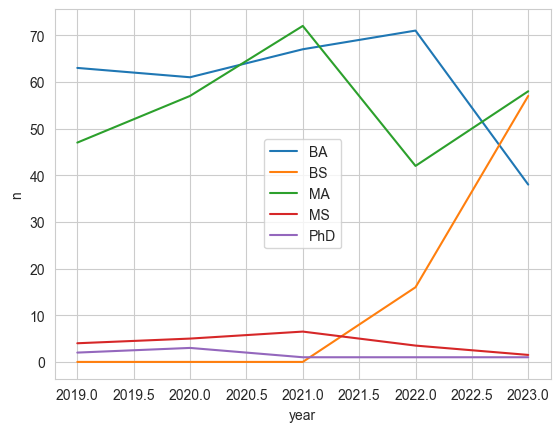

In [87]:
# add your code here
plt.Figure(figsize=(18,8))
sns.lineplot(data=melted_copy, x='year',y='n',ci=None,hue='degree_type', markers='o')
plt.legend()
plt.show()

-   **Your turn:** What aspects of the plot need to be updated to go from the draft you created above to the [Goal] plot at the beginning of this application exercise.

*Add your response here.*

-   **Demo**: Update x-axis scale such that the years displayed go from 2019 to 2023 in unique years. Do this by adding on to your pipeline from earlier.

C:\Users\yashs\AppData\Local\Temp\ipykernel_27896\1057112536.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=melted_copy, x='year',y='n',ci=None,hue='degree_type', markers='o')


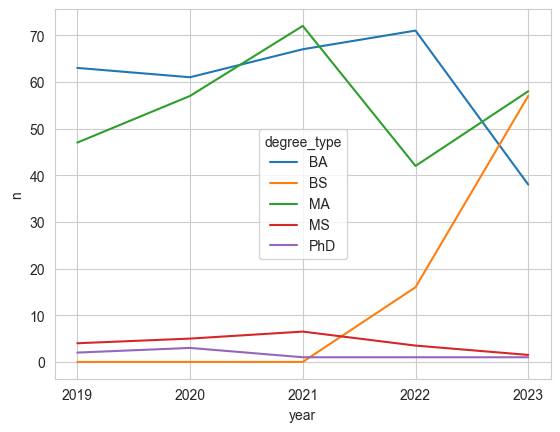

In [88]:
# add your code here
plt.Figure(figsize=(18,8))
sns.lineplot(data=melted_copy, x='year',y='n',ci=None,hue='degree_type', markers='o')
plt.xticks(ticks=melted_copy['year'].unique(),labels=melted_copy['year'].unique())
plt.legend(title='degree_type')
plt.show()

-   **Demo:** Update line colors using the following level / color assignments.
    Once again, do this by adding on to your pipeline from earlier.

    -   BA: "#53868B"

    -   BS: "#7AC5CD"

    -   MA: "#89a285"

    -   MS: "#8B814C"

    -   PhD: "#CDBE70"

C:\Users\yashs\AppData\Local\Temp\ipykernel_27896\2121126458.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=melted_copy, x='year',y='n',ci=None,hue='degree_type', markers='o', palette=custom_palette)


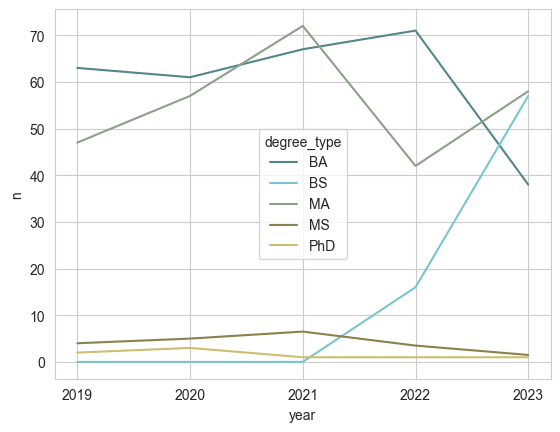

In [89]:
# add your code here
sns.set_style("whitegrid")

custom_palette= {
    "BA": "#53868B",
    "BS": "#7AC5CD",
    "MA": "#89a285",
    "MS": "#8B814C",
    "PhD": "#CDBE70"
}
plt.Figure(figsize=(18,8))
sns.lineplot(data=melted_copy, x='year',y='n',ci=None,hue='degree_type', markers='o', palette=custom_palette)
plt.xticks(ticks=melted_copy['year'].unique(),labels=melted_copy['year'].unique())
plt.legend(title='degree_type')
plt.show()

-   **Your turn:** Update the plot labels (`title`, `x`, and `y`) and use `sns.set_style("white_grid")`. Once again, do this by adding on to your pipeline from earlier.

C:\Users\yashs\AppData\Local\Temp\ipykernel_27896\3372582887.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=melted_copy, x='year',y='n',ci=None,hue='degree_type', markers='o', palette=custom_palette, linestyle='-', linewidth=3)


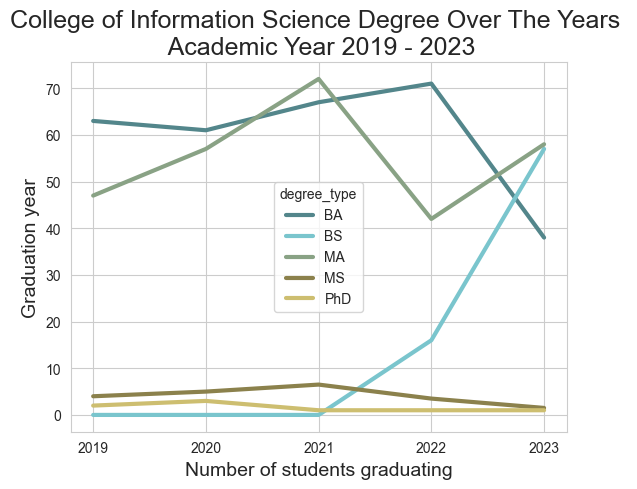

In [90]:
# add your code here
sns.set_style("whitegrid")
plt.Figure(figsize=(25,10))
sns.lineplot(data=melted_copy, x='year',y='n',ci=None,hue='degree_type', markers='o', palette=custom_palette, linestyle='-', linewidth=3)
plt.xticks(ticks=melted_copy['year'].unique(),labels=melted_copy['year'].unique())
plt.legend(title='degree_type')
plt.xlabel(xlabel='Number of students graduating',loc='center', fontsize=14)
plt.ylabel(ylabel='Graduation year', fontsize=14, loc='center')
plt.title(label="College of Information Science Degree Over The Years \n Academic Year 2019 - 2023", fontsize=18, loc='center')
plt.grid(True)
plt.show()